In [27]:
import pandas as pd
import scorecardpy as sc
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import pickle
import joblib
import os

In [3]:
train_woe = pd.read_csv('../data/processed/train_woe.csv')
test_woe = pd.read_csv('../data/processed/test_woe.csv')

In [4]:
target = 'target'
features = [
    'int_rate_woe', 'term_int_woe', 'dti_woe', 
    'revol_util_woe', 'annual_inc_woe', 'loan_amnt_woe', 'purpose_woe', 'inq_last_6mths_woe'
]

In [5]:
X_train = train_woe[features]
X_test = test_woe[features]
y_train = train_woe[target]
y_test = test_woe[target]

# Logistic Regression

In [6]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]

# Champion (XGBoost)

In [7]:
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

In [9]:
results = pd.DataFrame({
    'Actual': y_test,
    'LR_prob': lr_probs,
    'XGB_prob': xgb_probs
})

print(results.head(10))

   Actual   LR_prob  XGB_prob
0       0  0.316817  0.331857
1       0  0.117523  0.109945
2       0  0.125250  0.165997
3       1  0.173994  0.182726
4       0  0.204368  0.227113
5       0  0.214755  0.181945
6       1  0.382802  0.378904
7       0  0.294585  0.280782
8       0  0.462881  0.467191
9       0  0.193128  0.163448


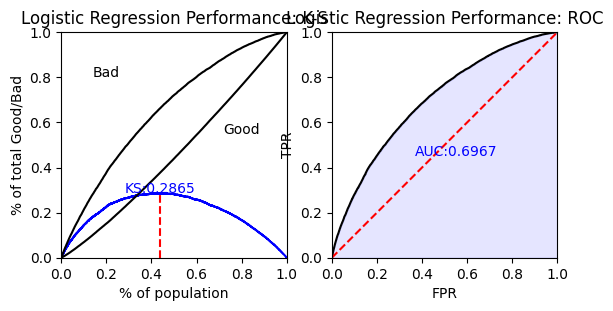

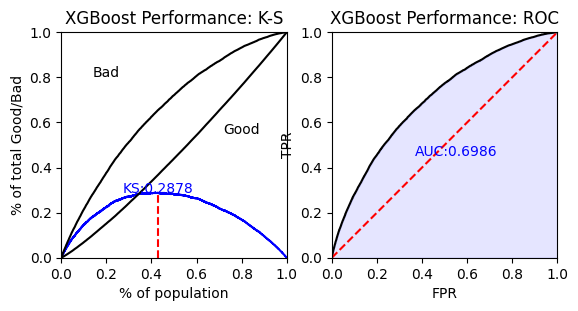

Gini Logistic Regression: 0.3934
Gini XGBoost: 0.3971


In [15]:
perf_lr = sc.perf_eva(y_test, lr_probs, title = "Logistic Regression Performance")
perf_xgb = sc.perf_eva(y_test, xgb_probs, title = "XGBoost Performance")

print(f"Gini Logistic Regression: {perf_lr['Gini']}")
print(f"Gini XGBoost: {perf_xgb['Gini']}")

In [17]:
from sklearn.model_selection import train_test_split
df = pd.read_csv('../data/processed/loan_data_stage_2.csv')
features = [
    'target',             
    'loan_amnt',         
    'term_int',           
    'int_rate',          
    'annual_inc',        
    'emp_length_int',   
    'home_ownership',    
    'dti',                
    'delinq_2yrs',        
    'inq_last_6mths',    
    'revol_util',        
    'total_acc',          
    'months_since_earliest_cr_line', 
    'purpose'             
]
df_f = df[features].copy()
cols_to_fix = ['delinq_2yrs', 'inq_last_6mths', 'revol_util', 'total_acc', 'months_since_earliest_cr_line']
for col in cols_to_fix:
    df_f[col] = df_f[col].fillna(df_f[col].median())
df_f['installment_to_inc'] = (df['installment'] * 12) / df['annual_inc']
df_f['loan_to_inc'] = df['loan_amnt'] / df['annual_inc']

features_extended = features + ['installment_to_inc', 'loan_to_inc']
train, test = train_test_split(df_f, test_size=0.3, random_state=42, stratify=df_f['target'])


In [18]:
bins = sc.woebin(train, y='target')
iv_list = []
for col in bins:
    iv_list.append({'feature': col, 'iv': bins[col]['total_iv'].iloc[0]})

iv_df = pd.DataFrame(iv_list).sort_values(by='iv', ascending=False)
print(iv_df)

[INFO] creating woe binning ...


c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed

Binning on 166386 rows and 16 columns in 00:00:20
                          feature        iv
0                        int_rate  0.387292
2                        term_int  0.161274
13                    loan_to_inc  0.152498
11             installment_to_inc  0.124583
8                             dti  0.087733
4                      revol_util  0.060531
5                      annual_inc  0.048562
14                      loan_amnt  0.031178
9                         purpose  0.020415
6                  inq_last_6mths  0.016563
7                  home_ownership  0.014320
3                  emp_length_int  0.005295
1                       total_acc  0.003830
12                    delinq_2yrs  0.003295
10  months_since_earliest_cr_line  0.002778


c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from th

In [19]:
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)

[INFO] converting into woe values ...
Woe transformating on 166386 rows and 15 columns in 00:00:10
[INFO] converting into woe values ...


In [20]:
features = [
    'int_rate_woe', 'term_int_woe', 'loan_to_inc_woe', 'installment_to_inc_woe', 'dti_woe', 'revol_util_woe', 'annual_inc_woe', 'loan_amnt_woe', 'purpose_woe'
]

In [21]:
X_train = train_woe[features]
X_test = test_woe[features]
y_train = train_woe[target]
y_test = test_woe[target]

In [23]:
lr1 = LogisticRegression(random_state=42)
lr1.fit(X_train, y_train)
lr1_probs = lr1.predict_proba(X_test)[:, 1]
xgb1 = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb1.fit(X_train, y_train)
xgb1_probs = xgb1.predict_proba(X_test)[:, 1]

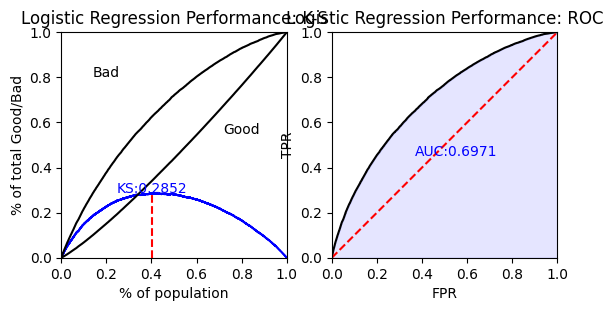

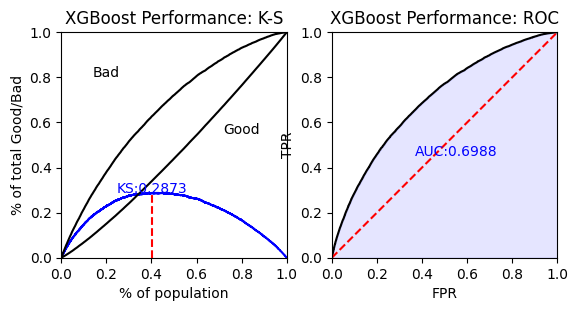

Gini Logistic Regression after tuning: 0.3942
Gini XGBoost after tuning: 0.3976


In [25]:
perf_lr1 = sc.perf_eva(y_test, lr1_probs, title = "Logistic Regression Performance")
perf_xgb1 = sc.perf_eva(y_test, xgb1_probs, title = "XGBoost Performance")

print(f"Gini Logistic Regression after tuning: {perf_lr1['Gini']}")
print(f"Gini XGBoost after tuning: {perf_xgb1['Gini']}")

После добавления двух новых признаков - installment_to_inc(Какую долю ежемесячного дохода съедает платеж по этому кредиту?) и loan_to_inc (Отношение суммы кредита к годовому доходу) мы дали модели немного контекста. Прирост в gini небольшой, и можем сказать что мы выжали из данных максимума. Точность у двух моделей почти одинаковая, и хоть XGBoost имеет чуть более лучшую точность, логистическая регрессия стабильна и легче интерпретируема, поэтому мы выберем ее.

In [26]:
with open('../data/processed/bins.pkl', 'wb') as f:
    pickle.dump(bins, f)

In [28]:
model_path = '../models'
os.makedirs(model_path)
joblib.dump(lr, f'{model_path}/credit_scoring_lr_model.pkl')

final_features = [col for col in X_train.columns] 
joblib.dump(final_features, f'{model_path}/features_list.pkl')

['../models/features_list.pkl']